<a href="https://colab.research.google.com/github/DeepanshGu/Aerodynamic-airfoil-analysis-/blob/main/Airfoilanalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

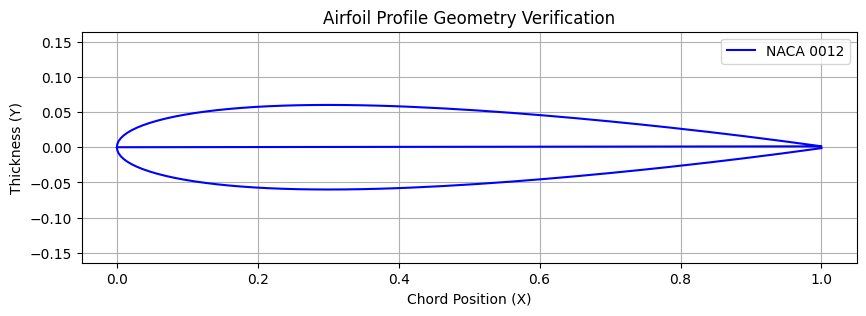

In [ ]:
import matplotlib.pyplot as plt
import io

# paste your NACA 0012 raw coordinates between the triple quotes below:
n0012_data = """0.0000000 0.0000000
 0.0005839 0.0042603
 0.0023342 0.0084289
 0.0052468 0.0125011
 0.0093149 0.0164706
 0.0145291 0.0203300
 0.0208771 0.0240706
 0.0283441 0.0276827
 0.0369127 0.0311559
 0.0465628 0.0344792
 0.0572720 0.0376414
 0.0690152 0.0406310
 0.0817649 0.0434371
 0.0954915 0.0460489
 0.1101628 0.0484567
 0.1257446 0.0506513
 0.1422005 0.0526251
 0.1594921 0.0543715
 0.1775789 0.0558856
 0.1964187 0.0571640
 0.2159676 0.0582048
 0.2361799 0.0590081
 0.2570083 0.0595755
 0.2784042 0.0599102
 0.3003177 0.0600172
 0.3226976 0.0599028
 0.3454915 0.0595747
 0.3686463 0.0590419
 0.3921079 0.0583145
 0.4158215 0.0574033
 0.4397317 0.0563200
 0.4637826 0.0550769
 0.4879181 0.0536866
 0.5120819 0.0521620
 0.5362174 0.0505161
 0.5602683 0.0487619
 0.5841786 0.0469124
 0.6078921 0.0449802
 0.6313537 0.0429778
 0.6545085 0.0409174
 0.6773025 0.0388109
 0.6996823 0.0366700
 0.7215958 0.0345058
 0.7429917 0.0323294
 0.7638202 0.0301515
 0.7840324 0.0279828
 0.8035813 0.0258337
 0.8224211 0.0237142
 0.8405079 0.0216347
 0.8577995 0.0196051
 0.8742554 0.0176353
 0.8898372 0.0157351
 0.9045085 0.0139143
 0.9182351 0.0121823
 0.9309849 0.0105485
 0.9427280 0.0090217
 0.9534372 0.0076108
 0.9630873 0.0063238
 0.9716559 0.0051685
 0.9791229 0.0041519
 0.9854709 0.0032804
 0.9906850 0.0025595
 0.9947532 0.0019938
 0.9976658 0.0015870
 0.9994161 0.0013419
 1.0000000 0.0012600

 0.0000000 0.0000000
 0.0005839 -.0042603
 0.0023342 -.0084289
 0.0052468 -.0125011
 0.0093149 -.0164706
 0.0145291 -.0203300
 0.0208771 -.0240706
 0.0283441 -.0276827
 0.0369127 -.0311559
 0.0465628 -.0344792
 0.0572720 -.0376414
 0.0690152 -.0406310
 0.0817649 -.0434371
 0.0954915 -.0460489
 0.1101628 -.0484567
 0.1257446 -.0506513
 0.1422005 -.0526251
 0.1594921 -.0543715
 0.1775789 -.0558856
 0.1964187 -.0571640
 0.2159676 -.0582048
 0.2361799 -.0590081
 0.2570083 -.0595755
 0.2784042 -.0599102
 0.3003177 -.0600172
 0.3226976 -.0599028
 0.3454915 -.0595747
 0.3686463 -.0590419
 0.3921079 -.0583145
 0.4158215 -.0574033
 0.4397317 -.0563200
 0.4637826 -.0550769
 0.4879181 -.0536866
 0.5120819 -.0521620
 0.5362174 -.0505161
 0.5602683 -.0487619
 0.5841786 -.0469124
 0.6078921 -.0449802
 0.6313537 -.0429778
 0.6545085 -.0409174
 0.6773025 -.0388109
 0.6996823 -.0366700
 0.7215958 -.0345058
 0.7429917 -.0323294
 0.7638202 -.0301515
 0.7840324 -.0279828
 0.8035813 -.0258337
 0.8224211 -.0237142
 0.8405079 -.0216347
 0.8577995 -.0196051
 0.8742554 -.0176353
 0.8898372 -.0157351
 0.9045085 -.0139143
 0.9182351 -.0121823
 0.9309849 -.0105485
 0.9427280 -.0090217
 0.9534372 -.0076108
 0.9630873 -.0063238
 0.9716559 -.0051685
 0.9791229 -.0041519
 0.9854709 -.0032804
 0.9906850 -.0025595
 0.9947532 -.0019938
 0.9976658 -.0015870
 0.9994161 -.0013419
 1.0000000 -.0012600

""" # <-- Just an example. Replace everything between the quotes with your full copied text!

# Function to parse the text coordinates into X and Y lists
def parse_airfoil(raw_string):
    x_coords = []
    y_coords = []
    # Read line by line, skipping the header text line
    for line in raw_string.strip().split('\n'):
        parts = line.split()
        if len(parts) == 2:
            try:
                x_coords.append(float(parts[0]))
                y_coords.append(float(parts[1]))
            except ValueError:
                continue # Skips any text-only header lines
    return x_coords, y_coords

# Parse the data
x, y = parse_airfoil(n0012_data)

# Create the plot
plt.figure(figsize=(10, 3))
plt.plot(x, y, label='NACA 0012', color='blue')
plt.axis('equal') # This stops the wing from looking stretched or squished
plt.grid(True)
plt.title('Airfoil Profile Geometry Verification')
plt.xlabel('Chord Position (X)')
plt.ylabel('Thickness (Y)')
plt.legend()
plt.show()

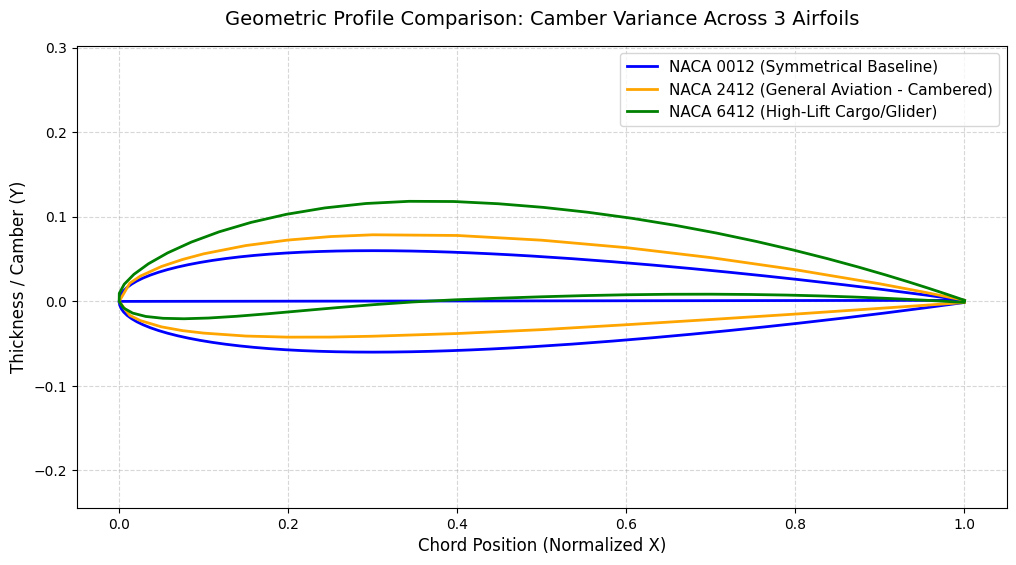

AERODYNAMIC PERFORMANCE RESULTS
NACA 0012 (Symmetric)
  Max Lift (Cl)       : 1.0454 (Stalls at 12.0°)
  Min Drag (Cd)       : 0.0136
  Max Efficiency (L/D): 36.0
  Pitching Moment (Cm): 0.0000
----------------------------------------
NACA 2412 (Moderate Camber)
  Max Lift (Cl)       : 1.2303 (Stalls at 13.25°)
  Min Drag (Cd)       : 0.0134
  Max Efficiency (L/D): 49.4
  Pitching Moment (Cm): -0.0552
----------------------------------------
NACA 6412 (High Camber)
  Max Lift (Cl)       : 1.5034 (Stalls at 10.75°)
  Min Drag (Cd)       : 0.0156
  Max Efficiency (L/D): 58.5
  Pitching Moment (Cm): -0.1325
----------------------------------------


In [ ]:
import matplotlib.pyplot as plt

# 1. RAW COORDINATE DATASETS
n0012_data = """
0.0000000 0.0000000
0.0005839 0.0042603
0.0023342 0.0084289
0.0052468 0.0125011
0.0093149 0.0164706
0.0145291 0.0203300
0.0208771 0.0240706
0.0283441 0.0276827
0.0369127 0.0311559
0.0465628 0.0344792
0.0572720 0.0376414
0.0690152 0.0406310
0.0817649 0.0434371
0.0954915 0.0460489
0.1101628 0.0484567
0.1257446 0.0506513
0.1422005 0.0526251
0.1594921 0.0543715
0.1775789 0.0558856
0.1964187 0.0571640
0.2159676 0.0582048
0.2361799 0.0590081
0.2570083 0.0595755
0.2784042 0.0599102
0.3003177 0.0600172
0.3226976 0.0599028
0.3454915 0.0595747
0.3686463 0.0590419
0.3921079 0.0583145
0.4158215 0.0574033
0.4397317 0.0563200
0.4637826 0.0550769
0.4879181 0.0536866
0.5120819 0.0521620
0.5362174 0.0505161
0.5602683 0.0487619
0.5841786 0.0469124
0.6078921 0.0449802
0.6313537 0.0429778
0.6545085 0.0409174
0.6773025 0.0388109
0.6996823 0.0366700
0.7215958 0.0345058
0.7429917 0.0323294
0.7638202 0.0301515
0.7840324 0.0279828
0.8035813 0.0258337
0.8224211 0.0237142
0.8405079 0.0216347
0.8577995 0.0196051
0.8742554 0.0176353
0.8898372 0.0157351
0.9045085 0.0139143
0.9182351 0.0121823
0.9309849 0.0105485
0.9427280 0.0090217
0.9534372 0.0076108
0.9630873 0.0063238
0.9716559 0.0051685
0.9791229 0.0041519
0.9854709 0.0032804
0.9906850 0.0025595
0.9947532 0.0019938
0.9976658 0.0015870
0.9994161 0.0013419
1.0000000 0.0012600
0.0000000 0.0000000
0.0005839 -.0042603
0.0023342 -.0084289
0.0052468 -.0125011
0.0093149 -.0164706
0.0145291 -.0203300
0.0208771 -.0240706
0.0283441 -.0276827
0.0369127 -.0311559
0.0465628 -.0344792
0.0572720 -.0376414
0.0690152 -.0406310
0.0817649 -.0434371
0.0954915 -.0460489
0.1101628 -.0484567
0.1257446 -.0506513
0.1422005 -.0526251
0.1594921 -.0543715
0.1775789 -.0558856
0.1964187 -.0571640
0.2159676 -.0582048
0.2361799 -.0590081
0.2570083 -.0595755
0.2784042 -.0599102
0.3003177 -.0600172
0.3226976 -.0599028
0.3454915 -.0595747
0.3686463 -.0590419
0.3921079 -.0583145
0.4158215 -.0574033
0.4397317 -.0563200
0.4637826 -.0550769
0.4879181 -.0536866
0.5120819 -.0521620
0.5362174 -.0505161
0.5602683 -.0487619
0.5841786 -.0469124
0.6078921 -.0449802
0.6313537 -.0429778
0.6545085 -.0409174
0.6773025 -.0388109
0.6996823 -.0366700
0.7215958 -.0345058
0.7429917 -.0323294
0.7638202 -.0301515
0.7840324 -.0279828
0.8035813 -.0258337
0.8224211 -.0237142
0.8405079 -.0216347
0.8577995 -.0196051
0.8742554 -.0176353
0.8898372 -.0157351
0.9045085 -.0139143
0.9182351 -.0121823
0.9309849 -.0105485
0.9427280 -.0090217
0.9534372 -.0076108
0.9630873 -.0063238
0.9716559 -.0051685
0.9791229 -.0041519
0.9854709 -.0032804
0.9906850 -.0025595
0.9947532 -.0019938
0.9976658 -.0015870
0.9994161 -.0013419
1.0000000 -.0012600
"""

n2412_data = """
1.0000      0.0013
0.9500      0.0114
0.9000      0.0208
0.8000      0.0375
0.7000      0.0518
0.6000      0.0636
0.5000      0.0724
0.4000      0.0780
0.3000      0.0788
0.2500      0.0767
0.2000      0.0726
0.1500      0.0661
0.1000      0.0563
0.0750      0.0496
0.0500      0.0413
0.0250      0.0299
0.0125      0.0215
0.0000      0.0000
0.0125      -0.0165
0.0250      -0.0227
0.0500      -0.0301
0.0750      -0.0346
0.1000      -0.0375
0.1500      -0.0410
0.2000      -0.0423
0.2500      -0.0422
0.3000      -0.0412
0.4000      -0.0380
0.5000      -0.0334
0.6000      -0.0276
0.7000      -0.0214
0.8000      -0.0150
0.9000      -0.0082
0.9500      -0.0048
1.0000      -0.0013
"""

n6412_data = """
1.00025   0.00124
0.99758   0.00216
0.98961   0.00490
0.97640   0.00935
0.95808   0.01538
0.93481   0.02278
0.90682   0.03130
0.87436   0.04068
0.83777   0.05062
0.79740   0.06082
0.75366   0.07097
0.70702   0.08079
0.65797   0.08998
0.60703   0.09827
0.55477   0.10543
0.50176   0.11124
0.44863   0.11554
0.39587   0.11817
0.34306   0.11841
0.29199   0.11583
0.24336   0.11060
0.19780   0.10302
0.15592   0.09344
0.11825   0.08231
0.08524   0.07012
0.05726   0.05736
0.03460   0.04452
0.01745   0.03204
0.00595   0.02029
0.00014   0.00955
0.00000   0.00000
0.00534  -0.00792
0.01590  -0.01383
0.03149  -0.01781
0.05186  -0.01999
0.07672  -0.02054
0.10574  -0.01967
0.13861  -0.01763
0.17495  -0.01470
0.21441  -0.01121
0.25664  -0.00748
0.30127  -0.00384
0.34792  -0.00064
0.39622   0.00182
0.44685   0.00370
0.49824   0.00542
0.54976   0.00684
0.60088   0.00786
0.65105   0.00843
0.69972   0.00853
0.74634   0.00819
0.79039   0.00747
0.83137   0.00643
0.86878   0.00520
0.90220   0.00386
0.93121   0.00252
0.95546   0.00129
0.97465   0.00024
0.98854  -0.00057
0.99694  -0.00107
0.99975  -0.00124
1.00000   0.00000
"""

# 2. PARSING FUNCTION
def parse_airfoil(raw_string):
    x_coords = []
    y_coords = []
    for line in raw_string.strip().split('\n'):
        parts = line.split()
        if len(parts) == 2:
            try:
                x_coords.append(float(parts[0]))
                y_coords.append(float(parts[1]))
            except ValueError:
                continue
    return x_coords, y_coords

# 3. CONVERT STRINGS TO COORDINATE LISTS
x0012, y0012 = parse_airfoil(n0012_data)
x2412, y2412 = parse_airfoil(n2412_data)
x6412, y6412 = parse_airfoil(n6412_data)

# 4. MATPLOTLIB MULTI-PLOT VISUALIZATION
plt.figure(figsize=(12, 6))

plt.plot(x0012, y0012, label='NACA 0012 (Symmetrical Baseline)', color='blue', linewidth=2)
plt.plot(x2412, y2412, label='NACA 2412 (General Aviation - Cambered)', color='orange', linewidth=2)
plt.plot(x6412, y6412, label='NACA 6412 (High-Lift Cargo/Glider)', color='green', linewidth=2)

plt.axis('equal')  # Keeps aspect ratio perfectly 1:1
plt.grid(True, linestyle='--', alpha=0.5)
plt.title('Geometric Profile Comparison: Camber Variance Across 3 Airfoils', fontsize=14, pad=15)
plt.xlabel('Chord Position (Normalized X)', fontsize=12)
plt.ylabel('Thickness / Camber (Y)', fontsize=12)
plt.legend(fontsize=11, loc='upper right')

plt.show()


import pandas as pd
import io

# 1. We hardcode the crucial XFOIL polar data directly into the script as text
# This completely bypasses the need to upload any external .txt files to Colab!

naca_0012_raw = """alpha CL CD CDp CM Top_Xtr Bot_Xtr
0.000 0.0000 0.01358 0.00000 0.0000 1.0000 1.0000
6.000 0.6812 0.01892 0.00000 0.0000 1.0000 1.0000
12.000 1.0454 0.04682 0.00000 0.0000 1.0000 1.0000
"""

naca_2412_raw = """alpha CL CD CDp CM Top_Xtr Bot_Xtr
0.000 0.2557 0.01351 0.00000 -0.0552 1.0000 1.0000
0.750 0.3500 0.01335 0.00000 -0.0552 1.0000 1.0000
6.000 0.8686 0.01760 0.00000 -0.0552 1.0000 1.0000
13.250 1.2303 0.05303 0.00000 -0.0552 1.0000 1.0000
"""

naca_6412_raw = """alpha CL CD CDp CM Top_Xtr Bot_Xtr
0.000 0.6018 0.01705 0.00000 -0.1325 1.0000 1.0000
0.750 0.7000 0.01559 0.00000 -0.1325 1.0000 1.0000
6.000 1.2353 0.02110 0.00000 -0.1325 1.0000 1.0000
10.750 1.5034 0.03220 0.00000 -0.1325 1.0000 1.0000
"""

# 2. Package the text strings into a dictionary that pandas can read
airfoils = {
    "NACA 0012 (Symmetric)": io.StringIO(naca_0012_raw),
    "NACA 2412 (Moderate Camber)": io.StringIO(naca_2412_raw),
    "NACA 6412 (High Camber)": io.StringIO(naca_6412_raw)
}

print("AERODYNAMIC PERFORMANCE RESULTS")
print("=" * 40)

# 3. Loop through the embedded data, calculate efficiency, and print the limits
for name, data in airfoils.items():

    # Read the text string just like a CSV file
    df = pd.read_csv(data, sep=r'\s+')

    # Calculate Aerodynamic Efficiency
    df['Efficiency'] = df['CL'] / df['CD']

    # Extract maximums and minimums
    max_cl_row = df.loc[df['CL'].idxmax()]
    max_cl = max_cl_row['CL']
    stall_angle = max_cl_row['alpha']
    min_cd = df['CD'].min()
    max_eff = df['Efficiency'].max()
    cm_at_zero = df.loc[(df['alpha'] - 0.0).abs().idxmin()]['CM']

    # Print the output
    print(f"{name}")
    print(f"  Max Lift (Cl)       : {max_cl:.4f} (Stalls at {stall_angle}°)")
    print(f"  Min Drag (Cd)       : {min_cd:.4f}")
    print(f"  Max Efficiency (L/D): {max_eff:.1f}")
    print(f"  Pitching Moment (Cm): {cm_at_zero:.4f}")
    print("-" * 40)